In [17]:
#imports
import os
from pathlib import Path
from PIL import Image
import cv2
import matplotlib
import matplotlib.pyplot as plt

# Disable LaTeX engine
matplotlib.rcParams['text.usetex'] = False

# (Optional but recommended)
matplotlib.rcParams['mathtext.default'] = 'regular'
print("Imported Successfully")

Imported Successfully


In [126]:
#variables
#char_set = "@#W$9876543210?!abc;:+=-,._"  # heavy → light
char_set = """$@B%8&WM#*oahkbdpqwmZO0QLCJUYXzcvunxrjft/\|()1{}[]?-_+~<>i!lI;:,"^`'."""
#char_set = "█▓▒░"
#char_set = "@. "

image_no = 8
width = 200

In [78]:
def image_to_ascii(image, width=120):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    aspect_ratio = h / w
    height = int(width * aspect_ratio * 0.55)

    resized = cv2.resize(gray, (width, height))

    ascii_img = []
    for row in resized:
        line = ""
        for pixel in row:
            idx = int(pixel / 255 * (len(char_set) - 1))
            line += char_set[idx]
        ascii_img.append(line)

    return ascii_img



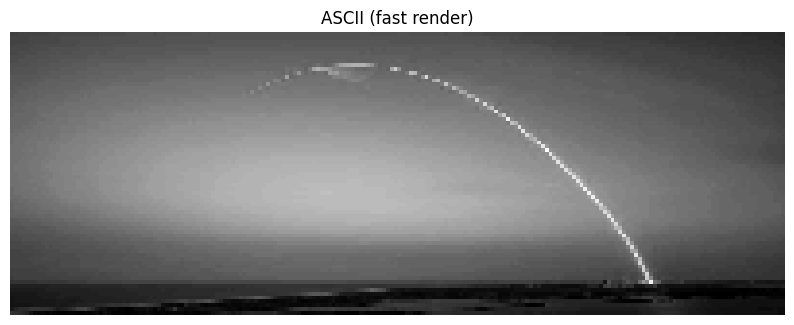

'\nplt.figure(figsize=(10, 15))  # taller figure\n\n# ORIGINAL IMAGE (TOP)\nplt.subplot(2,1,1)\nplt.imshow(img_rgb)\nplt.title(f"Original: {name}")\nplt.axis("off")\n\n# ASCII IMAGE (BOTTOM)\nplt.subplot(2,1,2)\nplt.title("ASCII Representation")\nplt.axis("off")\n\nplt.text(\n    0, 1,   # ← start from top-left\n    "\n".join(ascii_img),\n    fontfamily="monospace",\n    fontsize=6,\n    va="top",        # anchor text from top\n    ha="left",\n    parse_math=False\n)\n\nplt.tight_layout()\nplt.show()'

In [127]:
#Testing
#Load images from folder in bulk

imgfolder = "resized_images"
images = []

for filename in os.listdir(imgfolder):
    path = os.path.join(imgfolder, filename)
    img = cv2.imread(path)
    images.append((filename, img))

name,img = images[image_no-1]
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
ascii_img = image_to_ascii(img_rgb,width)


def ascii_to_image_fast(ascii_img, char_set):
    import numpy as np

    h = len(ascii_img)
    w = len(ascii_img[0])

    # map each char → intensity index
    char_to_idx = {ch: i for i, ch in enumerate(char_set)}

    img = np.zeros((h, w), dtype=np.float32)

    for i, row in enumerate(ascii_img):
        for j, ch in enumerate(row):
            img[i, j] = char_to_idx.get(ch, 0)

    # normalize to 0–255
    img = (img / (len(char_set) - 1)) * 255

    return img.astype(np.uint8)


ascii_render = ascii_to_image_fast(ascii_img, char_set)

plt.figure(figsize=(10,10))
plt.imshow(ascii_render, cmap="gray")
plt.title("ASCII (fast render)")
plt.axis("off")
plt.show()
"""
plt.figure(figsize=(10, 15))  # taller figure

# ORIGINAL IMAGE (TOP)
plt.subplot(2,1,1)
plt.imshow(img_rgb)
plt.title(f"Original: {name}")
plt.axis("off")

# ASCII IMAGE (BOTTOM)
plt.subplot(2,1,2)
plt.title("ASCII Representation")
plt.axis("off")

plt.text(
    0, 1,   # ← start from top-left
    "\n".join(ascii_img),
    fontfamily="monospace",
    fontsize=6,
    va="top",        # anchor text from top
    ha="left",
    parse_math=False
)

plt.tight_layout()
plt.show()"""

